# Compare Consolidated vs Clustered Renewable Datasets

**Objective:** Compare the old consolidated renewable data structure with the new clustered approach.

- **Consolidated:** Individual renewable sites flattened into `(region, site_id, time)` where `site_id` encodes technology + class
- **Clustered:** K-means aggregated pseudo-generators with explicit dimensions `(region, technology, class, time)`

**Key Comparisons:**
1. Capacity preservation: total MW before/after clustering
2. Merit-order scatter plots: avg_cf vs p_nom_max
3. Timeseries preservation: representative timeseries quality
4. Regional capacity distribution by technology
5. Cluster quality metrics: size distribution, temporal patterns

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
import json

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
logging.basicConfig(level=logging.INFO, format="%(message)s")

BASE_DIR = Path("../..")
CONSOLIDATED_FILE = BASE_DIR / "data/new_renewables_consolidated.nc"
CLUSTERED_FILE = BASE_DIR / "resources/renewables_clustered.nc"
CLUSTER_META_FILE = BASE_DIR / "resources/clusters_cache.json"

print(f"Consolidated: {'✓' if CONSOLIDATED_FILE.exists() else '✗'} {CONSOLIDATED_FILE}")
print(f"Clustered:    {'✓' if CLUSTERED_FILE.exists() else '✗'} {CLUSTERED_FILE}")
print(f"Metadata:     {'✓' if CLUSTER_META_FILE.exists() else '✗'} {CLUSTER_META_FILE}")

ds_clustered = None
df_cluster_meta = None
clustered_source = None

if CLUSTERED_FILE.exists():
    try:
        ds_clustered = xr.open_dataset(CLUSTERED_FILE)
        clustered_source = "dataset"
    except Exception as e:
        print(f"⚠️  Could not open clustered dataset: {e}")

if ds_clustered is None and CLUSTER_META_FILE.exists():
    with open(CLUSTER_META_FILE, "r", encoding="utf-8") as f:
        cache_payload = json.load(f)
    meta_rows = []
    for cluster_name, info in cache_payload.get("metadata", {}).items():
        row = dict(info)
        row["cluster_name"] = cluster_name
        meta_rows.append(row)
    df_cluster_meta = pd.DataFrame(meta_rows)
    if not df_cluster_meta.empty:
        df_cluster_meta["technology"] = df_cluster_meta["technology"].astype(str)
        df_cluster_meta["region"] = df_cluster_meta["region"].astype(str)
    clustered_source = "metadata"
elif ds_clustered is not None:
    print(f"\n📁 Clustered: {CLUSTERED_FILE.name}")
    print(f"   Dimensions: {dict(ds_clustered.sizes)}")
    print(f"   Variables: {list(ds_clustered.data_vars)}")
else:
    print("\n⚠️  No clustered dataset or metadata cache found")

consolidated_exists = CONSOLIDATED_FILE.exists()
if consolidated_exists:
    print(f"\n📁 Consolidated: {CONSOLIDATED_FILE.name}")
    ds_consolidated = xr.open_dataset(CONSOLIDATED_FILE)
    print(f"   Dimensions: {dict(ds_consolidated.sizes)}")
    print(f"   Variables: {list(ds_consolidated.data_vars)}")
else:
    print("\n⚠️  Consolidated file not found")
    ds_consolidated = None

if df_cluster_meta is not None:
    print(f"\n📋 Loaded cluster metadata rows: {len(df_cluster_meta):,}")
    print(
        df_cluster_meta[
            [
                "region",
                "technology",
                "cluster_id",
                "n_buses_consolidated",
                "total_capacity_mw",
                "avg_cf",
            ]
        ]
        .head()
        .to_string(index=False)
    )

Consolidated: ✓ ..\..\data\new_renewables_consolidated.nc
Clustered:    ✗ ..\..\resources\renewables_clustered.nc
Metadata:     ✓ ..\..\resources\clusters_cache.json

📁 Consolidated: new_renewables_consolidated.nc


c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


   Dimensions: {'region': 15, 'technology': 3, 'class': 39, 'time': 8760}
   Variables: ['capacity', 'capacity_factor']

📋 Loaded cluster metadata rows: 1,160
           region technology  cluster_id  n_buses_consolidated  total_capacity_mw   avg_cf
North_West_Africa     onwind           0                    49       6.607149e+04 0.049405
North_West_Africa     onwind           1                    59       4.165129e+06 0.304651
North_West_Africa     onwind           2                    59       3.562013e+05 0.032658
North_West_Africa     onwind           3                    66       1.048077e+05 0.217946
North_West_Africa     onwind           4                    49       8.892041e+05 0.075501


In [12]:
print("\n" + "=" * 70)
print("CONSOLIDATED DATASET DIAGNOSTICS")
print("=" * 70)

print("Dimensions:", dict(ds_consolidated.sizes))
print("Coords:", list(ds_consolidated.coords))
print("Region sample:", [str(v) for v in ds_consolidated.region.values[:5]])
print("Technology values:", [str(v) for v in ds_consolidated.technology.values])

for tech_name in ["onwind", "solar"]:
    try:
        cap_values = ds_consolidated["capacity"].sel(technology=tech_name).values
        print(
            f"{tech_name}: selection shape {cap_values.shape}, total {float(np.nansum(cap_values)):.1f} MW"
        )
    except Exception as e:
        print(f"{tech_name}: selection failed -> {e}")

print("Capacity variable dims:", ds_consolidated["capacity"].dims)
print("Capacity variable shape:", ds_consolidated["capacity"].shape)


CONSOLIDATED DATASET DIAGNOSTICS
Dimensions: {'region': 15, 'technology': 3, 'class': 39, 'time': 8760}
Coords: ['region', 'technology', 'class', 'time']
Region sample: ['Central_America', 'East_Asia', 'East_East_Asia', 'Eurasia', 'Europe']
Technology values: ['windoffshore', 'pvplant', 'windonshore']
onwind: selection failed -> "not all values found in index 'technology'. Try setting the `method` keyword argument (example: method='nearest')."
solar: selection failed -> "not all values found in index 'technology'. Try setting the `method` keyword argument (example: method='nearest')."
Capacity variable dims: ('region', 'technology', 'class')
Capacity variable shape: (15, 3, 39)


In [ ]:
print("=" * 70)
print("LOADING RENEWABLE DATA")
print("=" * 70)

print(f"\n📁 Clustered: {CLUSTERED_FILE.name}")
ds_clustered = xr.open_dataset(CLUSTERED_FILE)
print(f"   Dimensions: {dict(ds_clustered.sizes)}")
print(f"   Variables: {list(ds_clustered.data_vars)}")

consolidated_exists = CONSOLIDATED_FILE.exists()
if consolidated_exists:
    print(f"\n📁 Consolidated: {CONSOLIDATED_FILE.name}")
    ds_consolidated = xr.open_dataset(CONSOLIDATED_FILE)
    print(f"   Dimensions: {dict(ds_consolidated.sizes)}")
    print(f"   Variables: {list(ds_consolidated.data_vars)}")
else:
    print("\n⚠️  Consolidated file not found")
    ds_consolidated = None

In [19]:
print("\n" + "=" * 70)
print("CLUSTER-LEVEL COMPARISON DATA")
print("=" * 70)

techs_to_compare = ["onwind", "solar"]
consolidated_tech_map = {
    "windonshore": "onwind",
    "pvplant": "solar",
}


def build_cluster_rows_from_consolidated(ds):
    rows = []
    for consolidated_tech_name, compare_tech_name in consolidated_tech_map.items():
        try:
            cap_da = ds["capacity"].sel(technology=consolidated_tech_name)
            cf_da = ds["capacity_factor"].sel(technology=consolidated_tech_name)
            avg_cf_da = cf_da.mean(dim="time", skipna=True)

            for region_name in ds.region.values:
                region_caps = cap_da.sel(region=region_name).values
                region_avg_cf = avg_cf_da.sel(region=region_name).values
                for class_idx in range(len(region_caps)):
                    capacity_mw = float(region_caps[class_idx])
                    avg_cf = float(region_avg_cf[class_idx])
                    if np.isnan(capacity_mw) or np.isnan(avg_cf):
                        continue
                    rows.append(
                        {
                            "source": "Consolidated",
                            "region": str(region_name),
                            "technology": str(compare_tech_name),
                            "cluster_id": int(class_idx),
                            "cluster_label": f"{compare_tech_name} {class_idx + 1}",
                            "capacity_mw": capacity_mw,
                            "avg_cf": avg_cf,
                        }
                    )
        except Exception as e:
            print(
                f"  Could not read consolidated clusters for {consolidated_tech_name}: {e}"
            )
    return rows


def build_cluster_rows_from_metadata(df_meta):
    rows = []
    subset = df_meta[df_meta["technology"].isin(techs_to_compare)].copy()
    for _, row in subset.iterrows():
        rows.append(
            {
                "source": "Clustered",
                "region": str(row["region"]),
                "technology": str(row["technology"]),
                "cluster_id": int(row["cluster_id"]),
                "cluster_label": f"{row['technology']} {int(row['cluster_id']) + 1}",
                "capacity_mw": float(row["total_capacity_mw"]),
                "avg_cf": float(row["avg_cf"]),
            }
        )
    return rows


consolidated_rows = (
    build_cluster_rows_from_consolidated(ds_consolidated)
    if consolidated_exists and ds_consolidated is not None
    else []
)
if df_cluster_meta is not None:
    clustered_rows = build_cluster_rows_from_metadata(df_cluster_meta)
elif ds_clustered is not None:
    clustered_rows = []
    for tech_name in techs_to_compare:
        try:
            cap_da = ds_clustered["capacity"].sel(technology=tech_name)
            avg_cf_da = ds_clustered["avg_cf"].sel(technology=tech_name)
            for region_name in ds_clustered.region.values:
                region_caps = cap_da.sel(region=region_name).values
                region_avg_cf = avg_cf_da.sel(region=region_name).values
                for class_idx in range(len(region_caps)):
                    capacity_mw = float(region_caps[class_idx])
                    avg_cf = float(region_avg_cf[class_idx])
                    if np.isnan(capacity_mw) or np.isnan(avg_cf):
                        continue
                    clustered_rows.append(
                        {
                            "source": "Clustered",
                            "region": str(region_name),
                            "technology": str(tech_name),
                            "cluster_id": int(class_idx),
                            "cluster_label": f"{tech_name} {class_idx + 1}",
                            "capacity_mw": capacity_mw,
                            "avg_cf": avg_cf,
                        }
                    )
        except Exception as e:
            print(f"  Could not read clustered dataset for {tech_name}: {e}")
else:
    clustered_rows = []

comparison_df = pd.concat(
    [pd.DataFrame(consolidated_rows), pd.DataFrame(clustered_rows)], ignore_index=True
)

if comparison_df.empty:
    raise ValueError("No cluster-level data found.")

comparison_df["source"] = pd.Categorical(
    comparison_df["source"], categories=["Consolidated", "Clustered"], ordered=True
)
comparison_df["technology"] = pd.Categorical(
    comparison_df["technology"], categories=["solar", "onwind"], ordered=True
)
comparison_df["region"] = comparison_df["region"].astype(str)
comparison_df["avg_cf"] = comparison_df["avg_cf"].astype(float)

comparison_summary_df = (
    comparison_df.groupby(["source", "technology"], as_index=False)
    .agg(
        n_clusters=("cluster_id", "size"),
        total_capacity_mw=("capacity_mw", "sum"),
        mean_avg_cf=("avg_cf", "mean"),
    )
    .sort_values(["source", "technology"])
)

print("Cluster-level comparison summary:")
print("\n" + comparison_summary_df.to_string(index=False))

print("\nConsolidated cluster rows:", len(consolidated_rows))
print("Clustered cluster rows:   ", len(clustered_rows))
print("\nSample consolidated rows:")
print(pd.DataFrame(consolidated_rows).head().to_string(index=False))
print("\nSample clustered rows:")
print(pd.DataFrame(clustered_rows).head().to_string(index=False))


CLUSTER-LEVEL COMPARISON DATA
Cluster-level comparison summary:

      source technology  n_clusters  total_capacity_mw  mean_avg_cf
Consolidated      solar         157       1.421861e+08     0.197379
Consolidated     onwind         271       4.303580e+08     0.353087
   Clustered      solar         577       3.067626e+08     0.146385
   Clustered     onwind         583       2.633419e+08     0.169173

Consolidated cluster rows: 428
Clustered cluster rows:    1160

Sample consolidated rows:
      source          region technology  cluster_id cluster_label  capacity_mw   avg_cf
Consolidated Central_America     onwind           0      onwind 1 3.008679e+02 0.000000
Consolidated Central_America     onwind          20     onwind 21 1.269267e+02 0.007015
Consolidated Central_America     onwind          21     onwind 22 3.301898e+04 0.022544
Consolidated Central_America     onwind          22     onwind 23 3.193277e+05 0.049610
Consolidated Central_America     onwind          23     onwind 

C:\Users\JanLeopoldTautorus\AppData\Local\Temp\ipykernel_22260\854233552.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison_df.groupby(['source', 'technology'], as_index=False)


In [3]:
print("\n" + "=" * 70)
print("2. CLUSTERING STATISTICS")
print("=" * 70)

if df_cluster_meta is not None:
    cap_valid = df_cluster_meta["total_capacity_mw"].dropna().to_numpy()
    avg_cf_valid = df_cluster_meta["avg_cf"].dropna().to_numpy()
    n_total = len(df_cluster_meta)
else:
    cap_all = ds_clustered["capacity"].values.flatten()
    cap_valid = cap_all[~np.isnan(cap_all)]

    avg_cf_all = ds_clustered["avg_cf"].values.flatten()
    avg_cf_valid = avg_cf_all[~np.isnan(avg_cf_all)]

    n_total = len(cap_valid)

print(f"\nTotal clusters: {n_total:,}")
print("\nCapacity (MW):")
print(f"  Min:     {np.min(cap_valid):>12.1f}")
print(f"  Max:     {np.max(cap_valid):>12.1f}")
print(f"  Mean:    {np.mean(cap_valid):>12.1f}")
print(f"  Median:  {np.median(cap_valid):>12.1f}")
print(f"  Total:   {np.sum(cap_valid):>12.1f}")

print("\nAverage Capacity Factor:")
print(f"  Min:     {np.min(avg_cf_valid):>12.4f}")
print(f"  Max:     {np.max(avg_cf_valid):>12.4f}")
print(f"  Mean:    {np.mean(avg_cf_valid):>12.4f}")
print(f"  Median:  {np.median(avg_cf_valid):>12.4f}")


2. CLUSTERING STATISTICS

Total clusters: 1,160

Capacity (MW):
  Min:             43.0
  Max:       20293553.9
  Mean:        491469.4
  Median:      184945.5
  Total:    570104531.2

Average Capacity Factor:
  Min:           0.0000
  Max:           0.6988
  Mean:          0.1578
  Median:        0.1438



Generating Europe scatter plots with Seaborn...


C:\Users\JanLeopoldTautorus\AppData\Local\Temp\ipykernel_22260\4113124811.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df['cluster_order_key'] = plot_df.groupby(['source', 'technology']).cumcount()


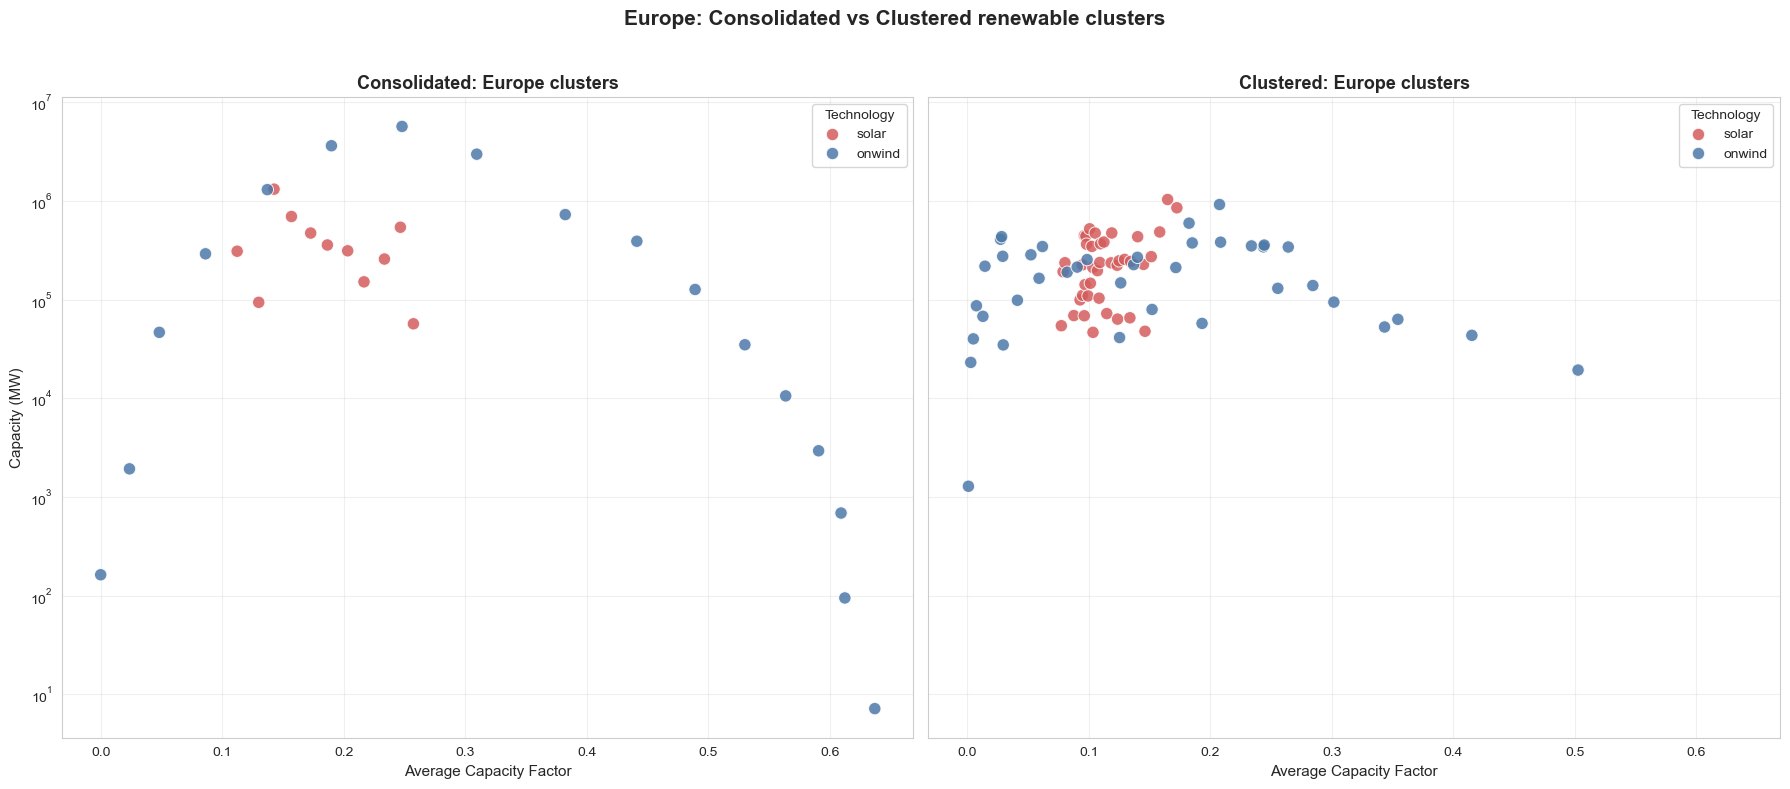

✓ Saved europe_cluster_scatter_comparison.png


In [17]:
print("\nGenerating scatter plot...")

region = (
    cluster_regions[0]
    if df_cluster_meta is not None
    else list(ds_clustered.region.values)[0]
)
tech = (
    cluster_techs[0]
    if df_cluster_meta is not None
    else list(ds_clustered.technology.values)[0]
)
print(f"Example: {region} - {tech}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if consolidated_exists:
    try:
        consol_cap = (
            ds_consolidated["capacity"].sel(region=region, technology=tech).values
        )
        if "avg_cf" in ds_consolidated.data_vars:
            consol_avg_cf = (
                ds_consolidated["avg_cf"].sel(region=region, technology=tech).values
            )
        else:
            cf_ts = (
                ds_consolidated["capacity_factor"]
                .sel(region=region, technology=tech)
                .values
            )
            consol_avg_cf = np.nanmean(cf_ts, axis=-1)

        valid = ~(np.isnan(consol_cap) | np.isnan(consol_avg_cf))
        axes[0].scatter(
            consol_avg_cf[valid], consol_cap[valid], alpha=0.4, s=30, c="steelblue"
        )
        axes[0].text(
            0.02,
            0.98,
            f"n={sum(valid)}",
            transform=axes[0].transAxes,
            va="top",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )
    except Exception as e:
        axes[0].text(
            0.5,
            0.5,
            f"Data not available: {e}",
            ha="center",
            va="center",
            transform=axes[0].transAxes,
        )
else:
    axes[0].text(
        0.5,
        0.5,
        "Consolidated file not available",
        ha="center",
        va="center",
        transform=axes[0].transAxes,
    )

axes[0].set_xlabel("Average Capacity Factor", fontsize=11)
axes[0].set_ylabel("P_nom_max (MW)", fontsize=11)
axes[0].set_title(
    f"Consolidated: {region} - {tech}\n(Individual Sites)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

try:
    if df_cluster_meta is not None:
        meta_sel = df_cluster_meta[
            (df_cluster_meta["region"] == region)
            & (df_cluster_meta["technology"] == tech)
        ]
        cluster_cap = meta_sel["total_capacity_mw"].to_numpy()
        cluster_avg_cf = meta_sel["avg_cf"].to_numpy()
    else:
        cluster_cap = (
            ds_clustered["capacity"].sel(region=region, technology=tech).values
        )
        cluster_avg_cf = (
            ds_clustered["avg_cf"].sel(region=region, technology=tech).values
        )
    valid = ~(np.isnan(cluster_cap) | np.isnan(cluster_avg_cf))
    axes[1].scatter(
        cluster_avg_cf[valid],
        cluster_cap[valid],
        alpha=0.7,
        s=120,
        c="coral",
        edgecolor="darkred",
    )
    axes[1].text(
        0.98,
        0.05,
        f"n_clusters={sum(valid)}",
        transform=axes[1].transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )
except Exception as e:
    axes[1].text(
        0.5, 0.5, f"Error: {e}", ha="center", va="center", transform=axes[1].transAxes
    )

axes[1].set_xlabel("Average Capacity Factor (Representative)", fontsize=11)
axes[1].set_ylabel("Cluster P_nom_max (MW)", fontsize=11)
axes[1].set_title(
    f"Clustered: {region} - {tech}\n(Pseudo-generators)", fontsize=12, fontweight="bold"
)
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scatter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved scatter_comparison.png")


Generating timeseries plot...


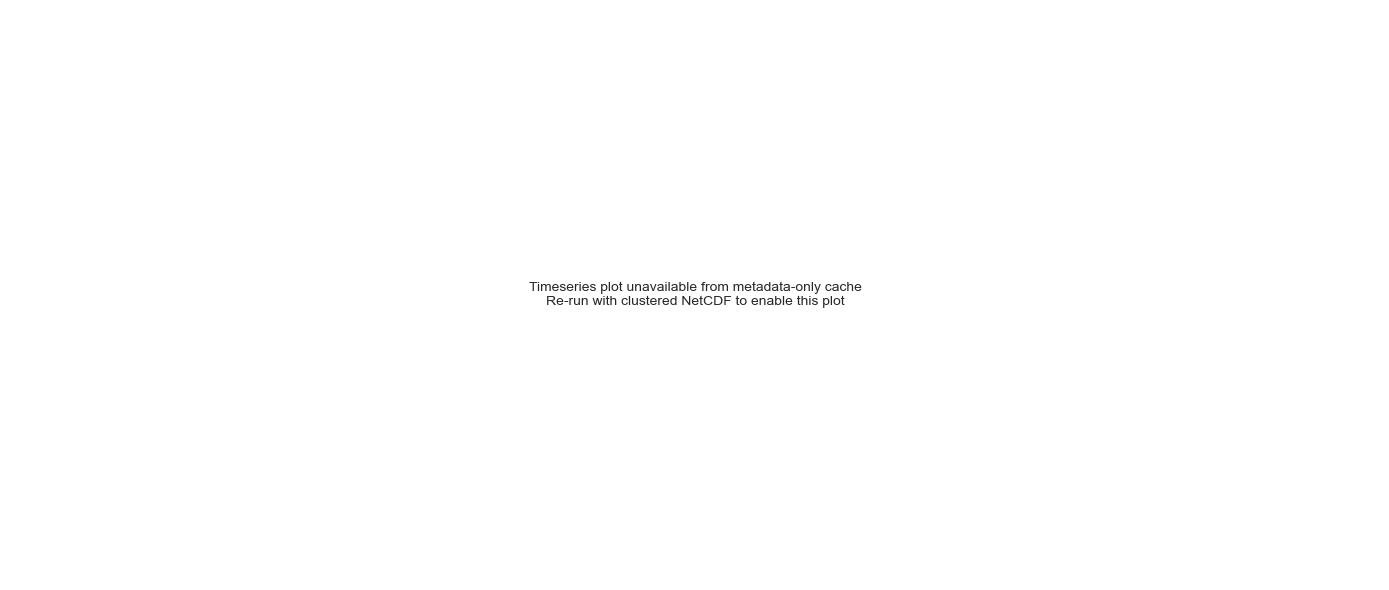

✓ Saved timeseries_clustered.png


In [5]:
print("\nGenerating timeseries plot...")

fig, ax = plt.subplots(figsize=(14, 6))

if df_cluster_meta is not None:
    ax.text(
        0.5,
        0.5,
        "Timeseries plot unavailable from metadata-only cache\nRe-run with clustered NetCDF to enable this plot",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
    ax.set_axis_off()
else:
    try:
        cf = ds_clustered["capacity_factor"].sel(region=region, technology=tech).values
        cap = ds_clustered["capacity"].sel(region=region, technology=tech).values
        max_cap = np.nanmax(cap)
        n_plotted = 0

        for cf_ts, c in zip(cf, cap):
            if not np.isnan(c) and not np.all(np.isnan(cf_ts)):
                cf_clean = np.nan_to_num(cf_ts, nan=0.0)
                lw = 0.5 + 3.5 * (c / max_cap) if max_cap > 0 else 1
                ax.plot(cf_clean, linewidth=lw, alpha=0.65)
                n_plotted += 1

        ax.set_xlabel("Hour of Year", fontsize=11)
        ax.set_ylabel("Capacity Factor", fontsize=11)
        ax.set_title(
            f"Clustered Timeseries: {region} - {tech}\n(Line width ∝ capacity, n_clusters={n_plotted})",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_ylim(-0.02, 1.05)
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.text(
            0.5, 0.5, f"Error: {e}", ha="center", va="center", transform=ax.transAxes
        )

plt.tight_layout()
plt.savefig("timeseries_clustered.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved timeseries_clustered.png")


Generating stacked region comparison by technology...


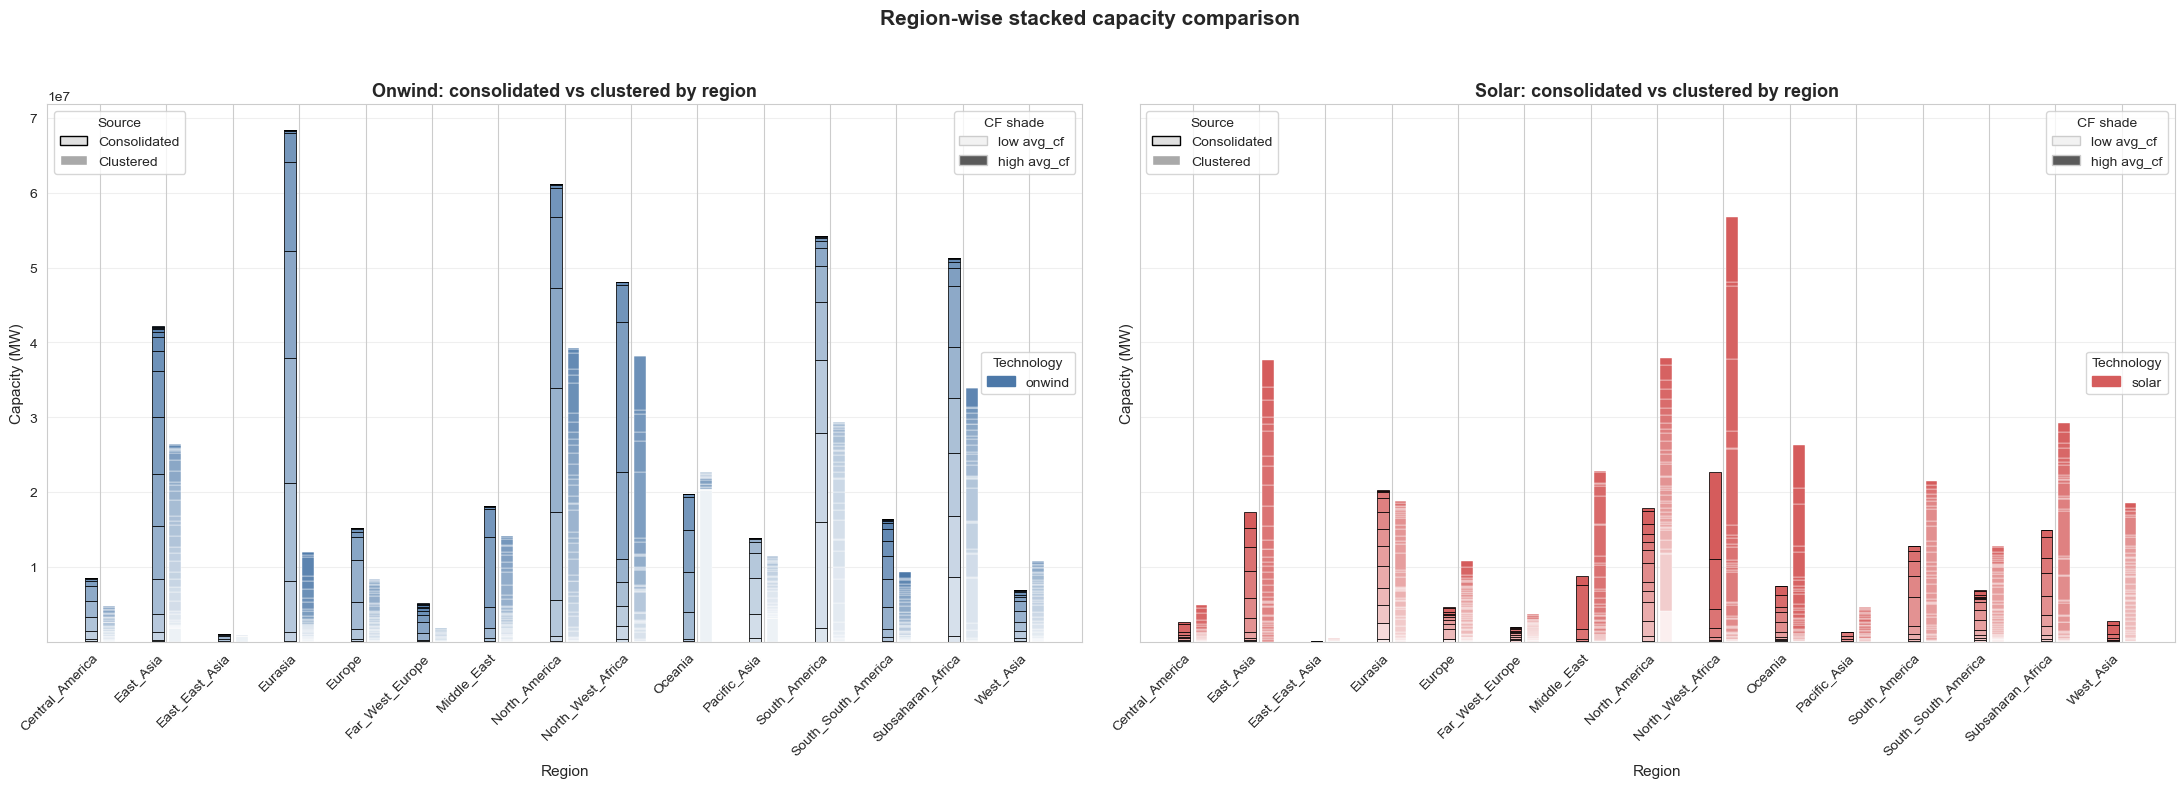

✓ Saved region_stacked_capacity_comparison.png


In [24]:
print("\nGenerating stacked region comparison by technology...")

sns.set_style("whitegrid")
tech_palette = {"solar": "#D55C5C", "onwind": "#4C78A8"}
source_offsets = {"Consolidated": -0.18, "Clustered": 0.18}
tech_width = 0.24
tech_order = ["solar", "onwind"]
source_order = ["Consolidated", "Clustered"]


def blend_with_white(color, intensity):
    base = np.array(sns.color_palette([color])[0])
    intensity = float(np.clip(intensity, 0.0, 1.0))
    return tuple(base * intensity + np.array([1.0, 1.0, 1.0]) * (1.0 - intensity))


def draw_tech_panel(ax, df, tech_name, title):
    regions = sorted(df["region"].unique())
    x_positions = np.arange(len(regions)) * 1.35

    for region_idx, region_name in enumerate(regions):
        for source_name in source_order:
            subset = df[
                (df["region"] == region_name)
                & (df["technology"] == tech_name)
                & (df["source"] == source_name)
            ].copy()
            if subset.empty:
                continue

            subset = subset.sort_values("avg_cf")
            bottom = 0.0
            cf_min = float(subset["avg_cf"].min())
            cf_max = float(subset["avg_cf"].max())
            cf_span = cf_max - cf_min if cf_max > cf_min else 1.0
            border_color = "black" if source_name == "Consolidated" else "white"
            border_width = 0.55 if source_name == "Consolidated" else 0.3

            for _, row in subset.iterrows():
                norm_cf = (row["avg_cf"] - cf_min) / cf_span
                shade = 0.10 + 0.90 * (norm_cf**0.65)
                color = blend_with_white(tech_palette[tech_name], shade)
                ax.bar(
                    x_positions[region_idx] + source_offsets[source_name],
                    row["capacity_mw"],
                    width=tech_width,
                    bottom=bottom,
                    color=color,
                    edgecolor=border_color,
                    linewidth=border_width,
                )
                bottom += row["capacity_mw"]

    import matplotlib.patches as mpatches

    source_handles = [
        mpatches.Patch(facecolor="#E0E0E0", edgecolor="black", label="Consolidated"),
        mpatches.Patch(facecolor="#A9A9A9", edgecolor="white", label="Clustered"),
    ]
    cf_handles = [
        mpatches.Patch(facecolor="#f2f2f2", edgecolor="#cccccc", label="low avg_cf"),
        mpatches.Patch(facecolor="#5a5a5a", edgecolor="#cccccc", label="high avg_cf"),
    ]
    tech_handles = [mpatches.Patch(color=tech_palette[tech_name], label=tech_name)]

    source_legend = ax.legend(handles=source_handles, title="Source", loc="upper left")
    ax.add_artist(source_legend)
    cf_legend = ax.legend(handles=cf_handles, title="CF shade", loc="upper right")
    ax.add_artist(cf_legend)
    ax.legend(handles=tech_handles, title="Technology", loc="center right")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Region", fontsize=11)
    ax.set_ylabel("Capacity (MW)", fontsize=11)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(regions, rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.margins(x=0.04)


fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=True)

draw_tech_panel(
    axes[0],
    comparison_df,
    "onwind",
    "Onwind: consolidated vs clustered by region",
)

draw_tech_panel(
    axes[1],
    comparison_df,
    "solar",
    "Solar: consolidated vs clustered by region",
)

fig.suptitle("Region-wise stacked capacity comparison", fontsize=15, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig("region_stacked_capacity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved region_stacked_capacity_comparison.png")


Generating cluster size distributions...


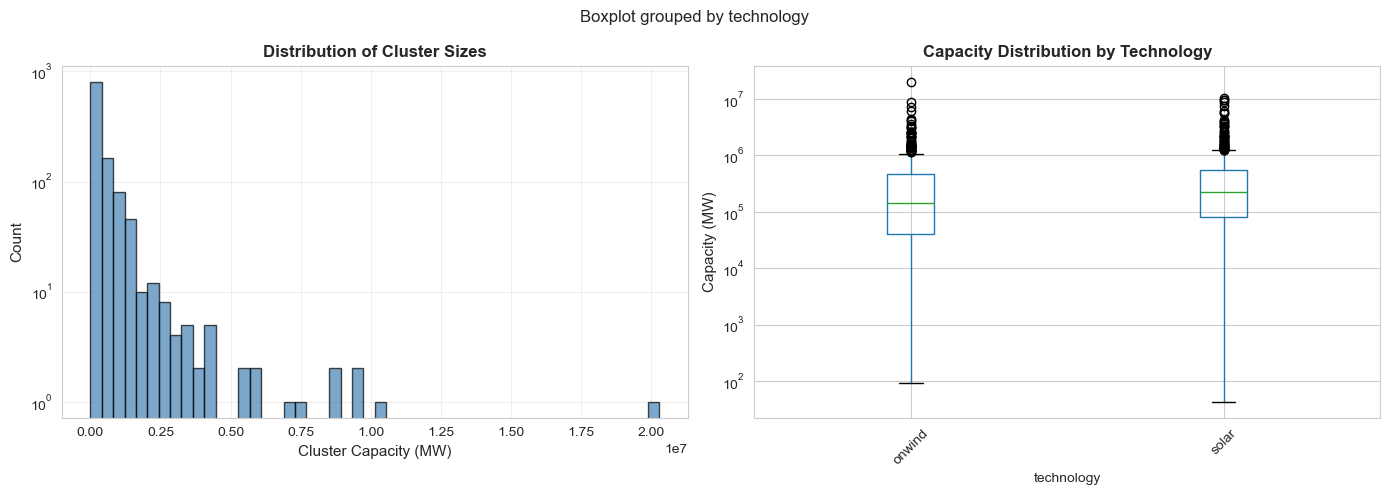

✓ Saved cluster_distributions.png


In [7]:
print("\nGenerating cluster size distributions...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cap_valid, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Cluster Capacity (MW)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Distribution of Cluster Sizes", fontsize=12, fontweight="bold")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

df_cap_by_tech = []
if df_cluster_meta is not None:
    for _, row in df_cluster_meta.iterrows():
        df_cap_by_tech.append(
            {"technology": row["technology"], "capacity_mw": row["total_capacity_mw"]}
        )
else:
    for t in ds_clustered.technology.values:
        try:
            cap_t = ds_clustered["capacity"].sel(technology=t).values.flatten()
            cap_t_valid = cap_t[~np.isnan(cap_t)]
            for c in cap_t_valid:
                df_cap_by_tech.append({"technology": str(t), "capacity_mw": c})
        except:
            pass

if df_cap_by_tech:
    df_box = pd.DataFrame(df_cap_by_tech)
    df_box.boxplot(column="capacity_mw", by="technology", ax=axes[1])
    axes[1].set_ylabel("Capacity (MW)", fontsize=11)
    axes[1].set_title(
        "Capacity Distribution by Technology", fontsize=12, fontweight="bold"
    )
    axes[1].set_yscale("log")
    plt.sca(axes[1])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("cluster_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved cluster_distributions.png")

In [8]:
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("\nClustering Results:")
if df_cluster_meta is not None:
    print(
        f"  Input:  {len(df_cluster_meta['region'].unique())} regions × {len(df_cluster_meta['technology'].unique())} technologies"
    )
    print(f"  Output: {len(df_cluster_meta):,} total clusters")
    print(f"  Total capacity: {df_cluster_meta['total_capacity_mw'].sum():.0f} MW")
else:
    print(
        f"  Input:  {len(ds_clustered.region.values)} regions × {len(ds_clustered.technology.values)} technologies"
    )
    print(f"  Output: {len(cap_valid):,} total clusters")
    print(f"  Total capacity: {np.sum(cap_valid):.0f} MW")

if consolidated_exists:
    cap_consol_all = ds_consolidated["capacity"].values.flatten()
    cap_consol_valid = cap_consol_all[~np.isnan(cap_consol_all)]
    if df_cluster_meta is not None:
        clustered_count = len(df_cluster_meta)
    else:
        clustered_count = len(cap_valid)
    if clustered_count > 0:
        compression = len(cap_consol_valid) / clustered_count
        print("\nCompression:")
        print(f"  Consolidated: {len(cap_consol_valid):,} sites")
        print(f"  Clustered:    {clustered_count:,} clusters")
        print(f"  Compression:  {compression:.1f}× reduction")

print("\n✅ Analysis complete! Generated 4 PNG plots in current directory.")
if df_cluster_meta is not None:
    print(
        "\nNote: timeseries plot is skipped because the JSON cache only contains metadata, not cf timeseries."
    )


SUMMARY

Clustering Results:
  Input:  15 regions × 2 technologies
  Output: 1,160 total clusters
  Total capacity: 570104531 MW

Compression:
  Consolidated: 1,755 sites
  Clustered:    1,160 clusters
  Compression:  1.5× reduction

✅ Analysis complete! Generated 4 PNG plots in current directory.

Note: timeseries plot is skipped because the JSON cache only contains metadata, not cf timeseries.
